# Aerospace Spare Parts Optimization

This notebook formulates and solves a **multi-period aerospace spare parts distribution problem** using **Mixed Integer Linear Programming (MILP)**.

We use the `PuLP` Python library to:

- Minimize the total cost (transport, purchase, holding, shortage, and fixed ordering).
- Manage spare parts inventories at bases.
- Satisfy demand at multiple stations.
- Handle truck capacity limits and optional air shipments.
- Incorporate repair returns and order lead times.

---

## Model Description

The **Aerospace Spare Parts Optimization Model** is a **Multi-Period MILP** designed to optimize the distribution and inventory management of spare parts in an aerospace logistics network.  

The model minimizes **total costs** (transportation, purchasing, holding, shortage, and fixed ordering costs), while ensuring demand satisfaction across multiple stations and managing inventory at bases. It incorporates real-world complexities such as truck capacity constraints, optional air shipments, repair returns, and order lead times.

---

## Key Components

### Entities
- **Bases**: Storage locations for spare parts (e.g., Delhi, Mumbai, Bengaluru).
- **Stations**: Demand points for spare parts (e.g., Kolkata, Hyderabad, Chennai).
- **Parts**: Two types of spare parts (P1, P2).
- **Periods**: Three planning periods.

---

### Decision Variables
- $Q_{b,p,t}$: Quantity of part $p$ ordered at base $b$ in period $t$.  
- $Y_{b,t}$: Binary variable indicating if an order is placed at base $b$ in period $t$.  
- $S_{b,s,p,t}^{truck}$: Quantity of part $p$ shipped via truck from base $b$ to station $s$ in period $t$.  
- $S_{b,s,p,t}^{air}$: Quantity of part $p$ shipped via air from base $b$ to station $s$ in period $t$.  
- $I_{b,p,t}$: Inventory level of part $p$ at base $b$ at the end of period $t$.  
- $C_{s,p,t}$: Quantity of part $p$ consumed at station $s$ in period $t$.  
- $H_{s,p,t}$: Shortage of part $p$ at station $s$ in period $t$.  

---

### Objective Function

The objective is to minimize the total cost:

$$
\min \sum_{b,s,p,t} \big( c_{b,s}^{truck} S_{b,s,p,t}^{truck} + c_{b,s}^{air} S_{b,s,p,t}^{air} \big) 
+ \sum_{b,p,t} p_p Q_{b,p,t} 
+ \sum_{b,t} f Y_{b,t} 
+ \sum_{b,p,t} h_p I_{b,p,t} 
+ \sum_{s,p,t} s_p H_{s,p,t}
$$

Where:
- $c_{b,s}^{truck}, c_{b,s}^{air}$: Transport costs.  
- $p_p$: Purchase cost.  
- $f$: Fixed ordering cost.  
- $h_p$: Holding cost.  
- $s_p$: Shortage cost.  

---

### Constraints

#### 1. Order Linking
$$
\sum_p Q_{b,p,t} \leq M \cdot Y_{b,t}, \quad \forall b,t
$$

---

#### 2. Truck Capacity
$$
\sum_{s,p} S_{b,s,p,t}^{truck} \leq K_b, \quad \forall b,t
$$

---

#### 3. Inventory Balance
$$
I_{b,p,t} =
\begin{cases}
I_{b,p,0} + Q_{b,p,t-1} + r_p \cdot \sigma_b \cdot \sum_s C_{s,p,t-1} - \sum_s (S_{b,s,p,t}^{truck} + S_{b,s,p,t}^{air}), & t = 1 \\
I_{b,p,t-1} + Q_{b,p,t-1} + r_p \cdot \sigma_b \cdot \sum_s C_{s,p,t-1} - \sum_s (S_{b,s,p,t}^{truck} + S_{b,s,p,t}^{air}), & t > 1
\end{cases}
$$

---

#### 4. Demand Satisfaction
$$
C_{s,p,t} + H_{s,p,t} = D_{s,p,t}, \quad \forall s,p,t
$$

---

#### 5. Flow Conservation
$$
\sum_b \big(S_{b,s,p,t}^{truck} + S_{b,s,p,t}^{air}\big) = C_{s,p,t}, \quad \forall s,p,t
$$

---

## Solver Details

This MILP is solved using **CBC (Coin - or Branch and Cut)** with `PuLP`. It is a Multi-period Mixed-Integer Linear Programming (MILP) which uses Simplex (for LP relaxations) inside Branch-and-Bound + Cutting Planes (to handle binaries).

### Configuration
- Time Limit: 60 seconds  
- Strategy: Branch-and-Bound with Cuts  

### Performance
- Optimal Objective: **1421.79 (₹k)**  
- Solve Time: **0.185 sec**  
- Nodes Explored: **10**  
- Iterations: **2486**  

---

### Output
- 279 probing cuts, 213 Gomory cuts applied.  
- Objective improved: **1264.21 → 1354.75 → 1421.79**  
- Final solution after **24 root cuts + branching**  

<a id="table-of-contents"></a>
## Table of Contents
- [Aerospace Spare Parts Optimization](#aerospace-spare-parts-optimization)
  - [Model Description](#model-description)
  - [Key Components](#key-components)
    - [Entities](#entities)
    - [Decision Variables](#decision-variables)
    - [Objective Function](#objective-function)
    - [Constraints](#constraints)
      - [1. Order Linking](#1-order-linking)
      - [2. Truck Capacity](#2-truck-capacity)
      - [3. Inventory Balance](#3-inventory-balance)
      - [4. Demand Satisfaction](#4-demand-satisfaction)
      - [5. Flow Conservation](#5-flow-conservation)
  - [Solver Details](#solver-details)
    - [Configuration](#configuration)
    - [Performance](#performance)
    - [Output](#output)
  - [1. Problem Data](#1-problem-data)
  - [2. Model Formulation](#2-model-formulation)
    - [Constraints](#constraints)
  - [3. Solve the Problem](#3-solve-the-problem)
  - [4. Results Summary](#4-results-summary)
  - [5. Visualize the results](#5-visualize-the-results)


In [1]:
# transport_spare_parts_milp.ipynb
import pulp
import time
import io
import sys
import pandas as pd
from IPython.display import display, Markdown

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## 1. Problem Data

We define:
- Bases: where parts are stored and shipped from.
- Stations: demand points for spare parts.
- Parts: two spare parts (`P1`, `P2`).
- Periods: 3 planning periods.

The dataset includes:
- Initial inventories.
- Demand forecasts.
- Transport costs (truck and air).
- Truck capacity.
- Purchase, holding, and shortage costs.
- Repair return fractions.

In [2]:
Bases = ["Delhi", "Mumbai", "Bengaluru"]
Stations = ["Kolkata", "Hyderabad", "Chennai"]
Parts = ["P1", "P2"]
Periods = [1, 2, 3]

# Initial inventories
init_inv = {
    ("Delhi", "P1"): 10,
    ("Delhi", "P2"): 5,
    ("Mumbai", "P1"): 8,
    ("Mumbai", "P2"): 8,
    ("Bengaluru", "P1"): 5,
    ("Bengaluru", "P2"): 10,
}

# Demand forecasts
demand = {
    1: {
        "Kolkata": {"P1": 8, "P2": 6},
        "Hyderabad": {"P1": 12, "P2": 10},
        "Chennai": {"P1": 10, "P2": 12},
    },
    2: {
        "Kolkata": {"P1": 10, "P2": 8},
        "Hyderabad": {"P1": 11, "P2": 11},
        "Chennai": {"P1": 12, "P2": 9},
    },
    3: {
        "Kolkata": {"P1": 9, "P2": 10},
        "Hyderabad": {"P1": 13, "P2": 12},
        "Chennai": {"P1": 11, "P2": 13},
    },
}

# Transport costs
truck_cost = {
    ("Delhi", "Kolkata"): 1.8,
    ("Delhi", "Hyderabad"): 2.0,
    ("Delhi", "Chennai"): 2.2,
    ("Mumbai", "Kolkata"): 2.1,
    ("Mumbai", "Hyderabad"): 1.9,
    ("Mumbai", "Chennai"): 2.0,
    ("Bengaluru", "Kolkata"): 2.6,
    ("Bengaluru", "Hyderabad"): 1.8,
    ("Bengaluru", "Chennai"): 1.6,
}
air_cost = {k: v + 1.5 for k, v in truck_cost.items()}

# Truck capacities
truck_capacity = {"Delhi": 25, "Mumbai": 20, "Bengaluru": 18}

# Cost parameters
purchase_cost = {"P1": 5.0, "P2": 7.0}
fixed_order_cost = 50.0
holding_cost = {"P1": 0.2, "P2": 0.25}
shortage_cost = {"P1": 20.0, "P2": 25.0}

# Repair return fractions
repair_return = {"P1": 0.20, "P2": 0.10}

# Big-M constant
BIGM = 1e6

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## 2. Model Formulation

- **Decision variables:**
  - Orders placed from suppliers.
  - Binary indicator for fixed order cost.
  - Shipments via truck and air.
  - Inventory at bases.
  - Shortages and consumed quantities at stations.

- **Objective:** Minimize total costs.
- **Constraints:**
  1. Order binary linking.
  2. Truck capacity.
  3. Inventory balance (with repair returns).
  4. Demand satisfaction (consumed + shortage).
  5. Flow conservation.

In [3]:
# Define model
model = pulp.LpProblem("Aerospace_Spare_Parts_MILP", pulp.LpMinimize)

# Decision variables
order_qty = pulp.LpVariable.dicts(
    "OrderQty", ((b, p, t) for b in Bases for p in Parts for t in Periods), lowBound=0
)
y_order = pulp.LpVariable.dicts(
    "Y_Order",
    ((b, t) for b in Bases for t in Periods),
    lowBound=0,
    upBound=1,
    cat="Binary",
)
ship_truck = pulp.LpVariable.dicts(
    "ShipTruck",
    ((b, s, p, t) for b in Bases for s in Stations for p in Parts for t in Periods),
    lowBound=0,
)
ship_air = pulp.LpVariable.dicts(
    "ShipAir",
    ((b, s, p, t) for b in Bases for s in Stations for p in Parts for t in Periods),
    lowBound=0,
)
inventory = pulp.LpVariable.dicts(
    "Inv", ((b, p, t) for b in Bases for p in Parts for t in Periods), lowBound=0
)
shortage = pulp.LpVariable.dicts(
    "Shortage",
    ((s, p, t) for s in Stations for p in Parts for t in Periods),
    lowBound=0,
)
consumed = pulp.LpVariable.dicts(
    "Consumed",
    ((s, p, t) for s in Stations for p in Parts for t in Periods),
    lowBound=0,
)

In [4]:
# Objective function
transport_cost = pulp.lpSum(
    [
        truck_cost[(b, s)] * ship_truck[(b, s, p, t)]
        + air_cost[(b, s)] * ship_air[(b, s, p, t)]
        for b in Bases
        for s in Stations
        for p in Parts
        for t in Periods
    ]
)
purchase_cost_total = pulp.lpSum(
    [
        purchase_cost[p] * order_qty[(b, p, t)]
        for b in Bases
        for p in Parts
        for t in Periods
    ]
)
fixed_order_total = pulp.lpSum(
    [fixed_order_cost * y_order[(b, t)] for b in Bases for t in Periods]
)
holding_cost_total = pulp.lpSum(
    [
        holding_cost[p] * inventory[(b, p, t)]
        for b in Bases
        for p in Parts
        for t in Periods
    ]
)
shortage_cost_total = pulp.lpSum(
    [
        shortage_cost[p] * shortage[(s, p, t)]
        for s in Stations
        for p in Parts
        for t in Periods
    ]
)

model += (
    transport_cost
    + purchase_cost_total
    + fixed_order_total
    + holding_cost_total
    + shortage_cost_total
)

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

### Constraints

In [5]:
# 1) Order linking
for b in Bases:
    for t in Periods:
        model += (
            pulp.lpSum([order_qty[(b, p, t)] for p in Parts]) <= BIGM * y_order[(b, t)]
        )

# 2) Truck capacity
for b in Bases:
    for t in Periods:
        model += (
            pulp.lpSum([ship_truck[(b, s, p, t)] for s in Stations for p in Parts])
            <= truck_capacity[b]
        )

# 3) Inventory balance with returns
for b in Bases:
    for p in Parts:
        total_init = sum(init_inv.get((bb, p), 0) for bb in Bases)
        base_share = (
            init_inv.get((b, p), 0) / total_init if total_init > 0 else 1 / len(Bases)
        )
        for t in Periods:
            arrivals = order_qty[(b, p, t - 1)] if t - 1 >= 1 else 0
            returns = (
                repair_return[p]
                * base_share
                * pulp.lpSum([consumed[(s, p, t - 1)] for s in Stations])
                if t - 1 >= 1
                else 0
            )
            outflows = pulp.lpSum(
                [ship_truck[(b, s, p, t)] + ship_air[(b, s, p, t)] for s in Stations]
            )
            if t == 1:
                model += (
                    init_inv.get((b, p), 0) + arrivals + returns - outflows
                    == inventory[(b, p, t)]
                )
            else:
                model += (
                    inventory[(b, p, t - 1)] + arrivals + returns - outflows
                    == inventory[(b, p, t)]
                )

# 4) Demand satisfaction
for t in Periods:
    for s in Stations:
        for p in Parts:
            model += consumed[(s, p, t)] + shortage[(s, p, t)] == demand[t][s][p]

# 5) Flow conservation
for t in Periods:
    for s in Stations:
        for p in Parts:
            model += (
                pulp.lpSum(
                    [ship_truck[(b, s, p, t)] + ship_air[(b, s, p, t)] for b in Bases]
                )
                == consumed[(s, p, t)]
            )

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## 3. Solve the Problem

In [6]:
solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=60)
start = time.time()
old_stdout = sys.stdout
sys.stdout = mystdout = io.StringIO()
result = model.solve(solver)
sys.stdout = old_stdout
end = time.time()
cbc_log = mystdout.getvalue().splitlines()

from IPython.display import display, Markdown

display(Markdown(f"### 🎯 Solver Results\n**Status:** {pulp.LpStatus[model.status]}\n**Objective (Total cost, ₹k):** {pulp.value(model.objective):.2f}\n**Solve Time:** {end - start:.3f} seconds"))


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/jules/.pyenv/versions/3.12.13/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/57651d86e8d7449bba3167bba7a707aa-pulp.mps -sec 60 -timeMode elapsed -branch -printingOptions all -solution /tmp/57651d86e8d7449bba3167bba7a707aa-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 77 COLUMNS
At line 696 RHS
At line 769 BOUNDS
At line 779 ENDATA
Problem MODEL has 72 rows, 189 columns and 429 elements
Coin0008I MODEL read with 0 errors
seconds was changed from 1e+100 to 60
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1264.21 - 0.00 seconds
Cgl0004I processed model has 51 rows, 162 columns (6 integer (6 of which binary)) and 384 elements
Cbc0038I Initial state - 6 integers unsatisfied sum - 0.0001127
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 3167.13 iterations 35
Cbc0038I Solution found of 3167.13
Cbc0038I 

.87 iterations 18
Cbc0038I Pass  36: suminf.    0.00005 (3) obj. 1394.87 iterations 0
Cbc0038I Pass  37: suminf.    0.00005 (3) obj. 1394.87 iterations 0
Cbc0038I Pass  38: suminf.    0.38681 (4) obj. 1394.87 iterations 6
Cbc0038I Pass  39: suminf.    0.00006 (4) obj. 1394.87 iterations 11
Cbc0038I Pass  40: suminf.    0.00006 (4) obj. 1394.87 iterations 0
Cbc0038I Pass  41: suminf.    0.00010 (4) obj. 1394.87 iterations 19
Cbc0038I Pass  42: suminf.    0.00010 (4) obj. 1394.87 iterations 0
Cbc0038I Pass  43: suminf.    0.00010 (4) obj. 1394.87 iterations 0
Cbc0038I Pass  44: suminf.    0.38680 (4) obj. 1394.87 iterations 11
Cbc0038I Pass  45: suminf.    0.00004 (3) obj. 1394.87 iterations 15
Cbc0038I Pass  46: suminf.    0.00004 (3) obj. 1394.87 iterations 0
Cbc0038I Pass  47: suminf.    0.38681 (4) obj. 1394.87 iterations 18
Cbc0038I Pass  48: suminf.    0.38681 (4) obj. 1394.87 iterations 0
Cbc0038I Pass  49: suminf.    0.00006 (4) obj. 1394.87 iterations 6
Cbc0038I Pass  50: suminf

### 🎯 Solver Results
**Status:** Optimal
**Objective (Total cost, ₹k):** 1421.79
**Solve Time:** 0.312 seconds

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## 4. Results Summary

In [7]:
from IPython.display import display, HTML

# Helper to style dataframes
def style_dataframe(df, caption, cmap='Blues', header_color='#f4f4f4', header_text='#333'):
    return df.style.background_gradient(cmap=cmap) \
             .set_caption(caption) \
             .set_table_attributes(f'aria-label="{caption}"') \
             .set_table_styles([
                 {'selector': 'th', 'props': [('background-color', header_color), ('color', header_text), ('font-weight', 'bold'), ('text-align', 'center')]}, 
                 {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]}, 
                 {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('color', '#333')]} 
             ]) \
             .hide(axis='index') \
             .format(precision=1)

# Orders
order_table = []
for b in Bases:
    for t in Periods:
        for p in Parts:
            q = order_qty[(b, p, t)].value()
            if q and q > 1e-6:
                order_table.append([b, t, p, q])

if order_table:
    df_orders = pd.DataFrame(order_table, columns=["Base", "Period", "Part", "OrderQty"])
    display(style_dataframe(df_orders, "🚀 Orders Placed", cmap='GnBu'))
else:
    display(Markdown("### 🚀 Orders Placed\n*No orders placed.*"))

# Shipments
ship_rows = []
for b in Bases:
    for s in Stations:
        for p in Parts:
            for t in Periods:
                st = ship_truck[(b, s, p, t)].value() or 0.0
                sa = ship_air[(b, s, p, t)].value() or 0.0
                if st > 1e-6 or sa > 1e-6:
                    ship_rows.append([b, s, p, t, st, sa])

if ship_rows:
    df_ship = pd.DataFrame(ship_rows, columns=["Base", "Station", "Part", "Period", "Truck", "Air"])
    display(style_dataframe(df_ship, "🚚 Shipments", cmap='Oranges'))
else:
    display(Markdown("### 🚚 Shipments\n*No shipments.*"))

# Inventories
inv_rows = []
for b in Bases:
    for p in Parts:
        for t in Periods:
            inv = inventory[(b, p, t)].value() or 0.0
            if inv > 1e-6:
                inv_rows.append([b, p, t, inv])

if inv_rows:
    df_inv = pd.DataFrame(inv_rows, columns=["Base", "Part", "Period", "Inv_End"])
    display(style_dataframe(df_inv, "📦 Inventory Levels", cmap='Greens'))
else:
    display(Markdown("### 📦 Inventory Levels\n*No inventory.*"))

# Shortages
sh_rows = []
for s in Stations:
    for p in Parts:
        for t in Periods:
            sh = shortage[(s, p, t)].value() or 0.0
            if sh > 1e-6:
                sh_rows.append([s, p, t, sh])

if sh_rows:
    df_short = pd.DataFrame(sh_rows, columns=["Station", "Part", "Period", "Shortage"])
    display(style_dataframe(df_short, "⚠️ Shortages", cmap='Reds', header_color='#ffebee', header_text='#b71c1c'))
else:
    display(Markdown("### ⚠️ Shortages\n*No shortages.*"))


Base,Period,Part,OrderQty
Delhi,1,P1,27.1
Delhi,1,P2,16.9
Bengaluru,1,P1,27.7
Bengaluru,1,P2,41.0


Base,Station,Part,Period,Truck,Air
Delhi,Kolkata,P1,1,8.0,0.0
Delhi,Kolkata,P1,2,10.0,0.0
Delhi,Kolkata,P1,3,9.0,0.0
Delhi,Kolkata,P2,1,5.0,0.0
Delhi,Kolkata,P2,2,8.0,0.0
Delhi,Kolkata,P2,3,10.0,0.0
Delhi,Hyderabad,P1,1,2.0,0.0
Delhi,Hyderabad,P1,2,7.0,0.0
Delhi,Hyderabad,P1,3,6.0,0.0
Mumbai,Hyderabad,P1,1,8.0,0.0


Base,Part,Period,Inv_End
Delhi,P1,2,12.1
Delhi,P2,2,9.4
Bengaluru,P1,2,14.3
Bengaluru,P2,2,22.8


Station,Part,Period,Shortage
Kolkata,P2,1,1.0
Hyderabad,P1,1,2.0
Hyderabad,P2,1,2.0
Chennai,P1,1,5.0
Chennai,P2,1,2.0


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## 5. Visualize the results

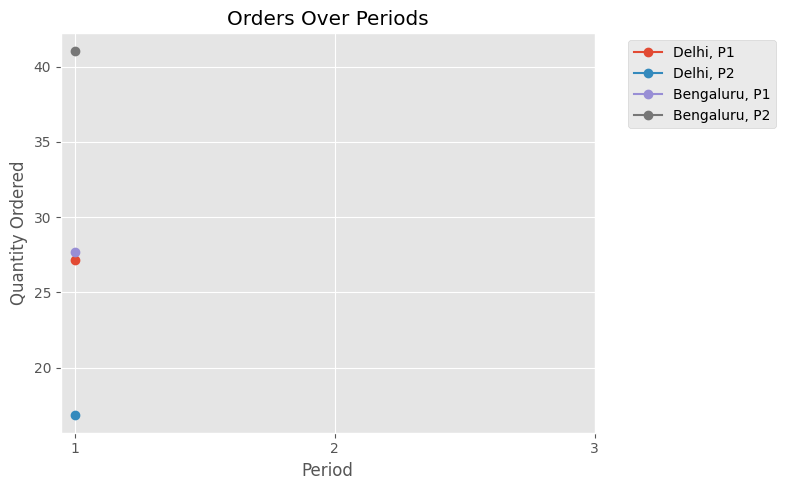

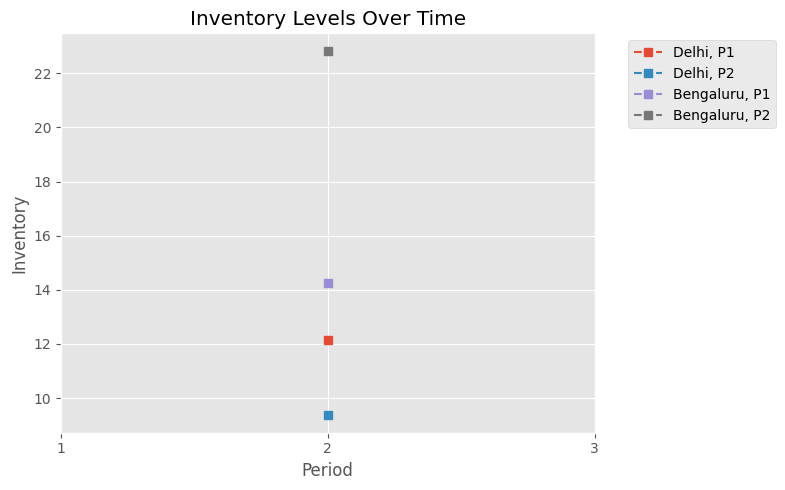

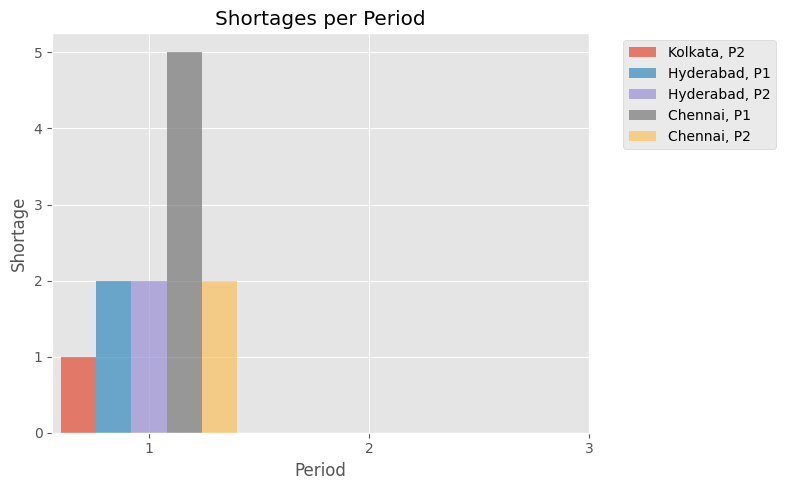

In [8]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# --- Orders over Periods ---
plt.figure(figsize=(8, 5))
for b in Bases:
    for p in Parts:
        x, y = [], []
        for t in Periods:
            val = order_qty[(b, p, t)].value()
            if val is not None and val > 1e-6:  # skip zero orders
                x.append(t)
                y.append(val)
        if x:  # only plot if there’s data
            plt.plot(x, y, marker="o", label=f"{b}, {p}")

plt.title("Orders Over Periods")
plt.xlabel("Period")
plt.xticks(Periods)
plt.ylabel("Quantity Ordered")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Inventory Levels ---
plt.figure(figsize=(8, 5))
for b in Bases:
    for p in Parts:
        x, y = [], []
        for t in Periods:
            val = inventory[(b, p, t)].value()
            if val is not None and val > 1e-6:
                x.append(t)
                y.append(val)
        if x:
            plt.plot(x, y, marker="s", linestyle="--", label=f"{b}, {p}")

plt.title("Inventory Levels Over Time")
plt.xlabel("Period")
plt.xticks(Periods)
plt.ylabel("Inventory")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Shortages ---
plt.figure(figsize=(8, 5))

# We have pairs of (Station, Part) to plot.
# Only a subset might actually have shortages.
# Let's collect which ones have data to dynamically adjust bar_width.
series_data = []
for s in Stations:
    for p in Parts:
        x, y = [], []
        for t in Periods:
            val = shortage[(s, p, t)].value()
            if val is not None and val > 1e-6:
                x.append(t)
                y.append(val)
        if x:
            series_data.append((f"{s}, {p}", x, y))

if series_data:
    n_series = len(series_data)
    bar_width = 0.8 / n_series
    
    for i, (label, x, y) in enumerate(series_data):
        # Calculate offset for each series
        offset = (i - n_series / 2) * bar_width + bar_width / 2
        x_offset = [val + offset for val in x]
        plt.bar(x_offset, y, width=bar_width, alpha=0.7, label=label)

plt.title("Shortages per Period")
plt.xlabel("Period")
plt.xticks(Periods)
plt.ylabel("Shortage")
if series_data:
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>